In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import requests
from datetime import datetime, timedelta
from datetime import datetime


from IPython.display import clear_output

%matplotlib inline

pd.set_option('display.max_columns', None)

In [13]:
# Директория для сохранения файлов
download_dir = "bybit_last_ETH"

# Скачивание файлов
base_url = "https://public.bybit.com/spot/ETHUSDT/ETHUSDT_{}.csv.gz"

# Тикер
ticker = 'ETHUSDT'

# Задаем интервал
interval = '15Min'

# Итоговый файл
output_file = "ETHUSDT_final_26_01_2026.csv"

# Начальная дата
start_date = datetime(2024, 1, 1)

In [14]:
os.makedirs(download_dir, exist_ok=True)

# Функция для скачивания файла
def download_file(url, file_path):
    response = requests.get(url, stream=True)
    if response.status_code == 200:
        with open(file_path, 'wb') as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
        print(f"Файл {file_path} успешно скачан.")
    else:
        print(f"Файл {url} не найден.")

# Генерация списка дат
end_date = datetime.now()
date_range = [start_date + timedelta(days=i) for i in range((end_date - start_date).days + 1)]

for date in date_range:
    date_str = date.strftime("%Y-%m-%d")  # Форматируем дату в строку
    file_url = base_url.format(date_str)
    file_name = f"{ticker}_{date_str}.csv.gz"
    file_path = os.path.join(download_dir, file_name)
    
    # Скачиваем файл
    download_file(file_url, file_path)

Файл bybit_last_ETH\ETHUSDT_2024-01-01.csv.gz успешно скачан.
Файл bybit_last_ETH\ETHUSDT_2024-01-02.csv.gz успешно скачан.
Файл bybit_last_ETH\ETHUSDT_2024-01-03.csv.gz успешно скачан.
Файл bybit_last_ETH\ETHUSDT_2024-01-04.csv.gz успешно скачан.
Файл bybit_last_ETH\ETHUSDT_2024-01-05.csv.gz успешно скачан.
Файл bybit_last_ETH\ETHUSDT_2024-01-06.csv.gz успешно скачан.
Файл bybit_last_ETH\ETHUSDT_2024-01-07.csv.gz успешно скачан.
Файл bybit_last_ETH\ETHUSDT_2024-01-08.csv.gz успешно скачан.
Файл bybit_last_ETH\ETHUSDT_2024-01-09.csv.gz успешно скачан.
Файл bybit_last_ETH\ETHUSDT_2024-01-10.csv.gz успешно скачан.
Файл bybit_last_ETH\ETHUSDT_2024-01-11.csv.gz успешно скачан.
Файл bybit_last_ETH\ETHUSDT_2024-01-12.csv.gz успешно скачан.
Файл bybit_last_ETH\ETHUSDT_2024-01-13.csv.gz успешно скачан.
Файл bybit_last_ETH\ETHUSDT_2024-01-14.csv.gz успешно скачан.
Файл bybit_last_ETH\ETHUSDT_2024-01-15.csv.gz успешно скачан.
Файл bybit_last_ETH\ETHUSDT_2024-01-16.csv.gz успешно скачан.
Файл byb

In [15]:
import warnings
warnings.filterwarnings('ignore')

In [16]:
import glob
files = glob.glob(os.path.join(download_dir, "*.csv.gz"))
df_test = pd.read_csv(files[0], compression='gzip')
df_test

,id,timestamp,price,volume,side
0,1,1704067201875,2282.00,0.07666,buy
1,2,1704067202639,2282.00,0.11000,buy
2,3,1704067202639,2282.00,0.04334,buy
3,4,1704067202646,2282.05,0.15000,buy
4,5,1704067202679,2282.10,1.93598,buy
...,...,...,...,...,...
149684,149685,1704153590922,2351.70,0.11000,sell
149685,149686,1704153591072,2351.51,0.08050,buy
149686,149687,1704153595671,2351.60,0.12000,buy
149687,149688,1704153595671,2351.60,0.20966,buy


In [17]:
# Функция для чтения и предварительной обработки одного файла
def read_file(file_path):
    # Чтение файла
    df = pd.read_csv(file_path, compression='gzip')
    
    # Преобразуем timestamp в datetime и устанавливаем его как индекс
    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
    df.set_index('timestamp', inplace=True)
    
    # Группируем по интервалам
    grouped = df.resample(interval)
    
    # Агрегируем данные для каждой свечи
    candles = grouped.agg(
        Open=('price', 'first'),
        High=('price', 'max'),
        Low=('price', 'min'),
        Close=('price', 'last'),
        Volume=('volume', 'sum')
    )
    
    # Сбрасываем индекс, чтобы Datetime стал колонкой
    candles.reset_index(inplace=True)
    
    return candles

# Список всех скачанных файлов
files = glob.glob(os.path.join(download_dir, "*.csv.gz"))

# Чтение и предварительная обработка всех файлов
all_candles = []
for file in files:
    print(f"Обрабатывается файл: {file}")
    processed_data = read_file(file)
    all_candles.append(processed_data)

# Объединение всех данных в один DataFrame
combined_candles = pd.concat(all_candles, ignore_index=True)

# Сортировка по времени (на случай, если файлы были обработаны в неправильном порядке)
combined_candles.sort_values(by='timestamp', inplace=True)

# Корректируем цену открытия: Open = предыдущий Close
combined_candles['Open'] = combined_candles['Close'].shift(1)

# Удаляем первую строку, так как для нее нет предыдущего значения Close
combined_candles.dropna(inplace=True)

Обрабатывается файл: bybit_last_ETH\ETHUSDT_2024-01-01.csv.gz
Обрабатывается файл: bybit_last_ETH\ETHUSDT_2024-01-02.csv.gz
Обрабатывается файл: bybit_last_ETH\ETHUSDT_2024-01-03.csv.gz
Обрабатывается файл: bybit_last_ETH\ETHUSDT_2024-01-04.csv.gz
Обрабатывается файл: bybit_last_ETH\ETHUSDT_2024-01-05.csv.gz
Обрабатывается файл: bybit_last_ETH\ETHUSDT_2024-01-06.csv.gz
Обрабатывается файл: bybit_last_ETH\ETHUSDT_2024-01-07.csv.gz
Обрабатывается файл: bybit_last_ETH\ETHUSDT_2024-01-08.csv.gz
Обрабатывается файл: bybit_last_ETH\ETHUSDT_2024-01-09.csv.gz
Обрабатывается файл: bybit_last_ETH\ETHUSDT_2024-01-10.csv.gz
Обрабатывается файл: bybit_last_ETH\ETHUSDT_2024-01-11.csv.gz
Обрабатывается файл: bybit_last_ETH\ETHUSDT_2024-01-12.csv.gz
Обрабатывается файл: bybit_last_ETH\ETHUSDT_2024-01-13.csv.gz
Обрабатывается файл: bybit_last_ETH\ETHUSDT_2024-01-14.csv.gz
Обрабатывается файл: bybit_last_ETH\ETHUSDT_2024-01-15.csv.gz
Обрабатывается файл: bybit_last_ETH\ETHUSDT_2024-01-16.csv.gz
Обрабаты

In [18]:
# Округляем колонку Volume до целых чисел
combined_candles['Volume'] = combined_candles['Volume'].round().astype(int)

In [19]:
combined_candles

,timestamp,Open,High,Low,Close,Volume
1,2024-01-01 00:15:00,2296.56,2296.90,2288.80,2290.90,1109
2,2024-01-01 00:30:00,2290.90,2294.40,2288.51,2293.19,953
3,2024-01-01 00:45:00,2293.19,2297.16,2292.30,2295.61,592
4,2024-01-01 01:00:00,2295.61,2297.20,2291.91,2296.40,1424
5,2024-01-01 01:15:00,2296.40,2300.17,2296.50,2298.95,496
...,...,...,...,...,...,...
72571,2026-01-25 22:45:00,2802.87,2807.22,2790.56,2807.22,832
72572,2026-01-25 23:00:00,2807.22,2809.64,2787.21,2801.06,2717
72573,2026-01-25 23:15:00,2801.06,2813.23,2792.41,2805.38,1664
72574,2026-01-25 23:30:00,2805.38,2810.10,2798.02,2802.43,1187


In [20]:
# Если надо обрезать
combined_candles = combined_candles.tail(200000)
combined_candles

,timestamp,Open,High,Low,Close,Volume
1,2024-01-01 00:15:00,2296.56,2296.90,2288.80,2290.90,1109
2,2024-01-01 00:30:00,2290.90,2294.40,2288.51,2293.19,953
3,2024-01-01 00:45:00,2293.19,2297.16,2292.30,2295.61,592
4,2024-01-01 01:00:00,2295.61,2297.20,2291.91,2296.40,1424
5,2024-01-01 01:15:00,2296.40,2300.17,2296.50,2298.95,496
...,...,...,...,...,...,...
72571,2026-01-25 22:45:00,2802.87,2807.22,2790.56,2807.22,832
72572,2026-01-25 23:00:00,2807.22,2809.64,2787.21,2801.06,2717
72573,2026-01-25 23:15:00,2801.06,2813.23,2792.41,2805.38,1664
72574,2026-01-25 23:30:00,2805.38,2810.10,2798.02,2802.43,1187


In [21]:
# Сохранение в файл
combined_candles.to_csv(output_file, index=False)

print(f"Сохранено в файл: {output_file}")

Сохранено в файл: ETHUSDT_final_26_01_2026.csv


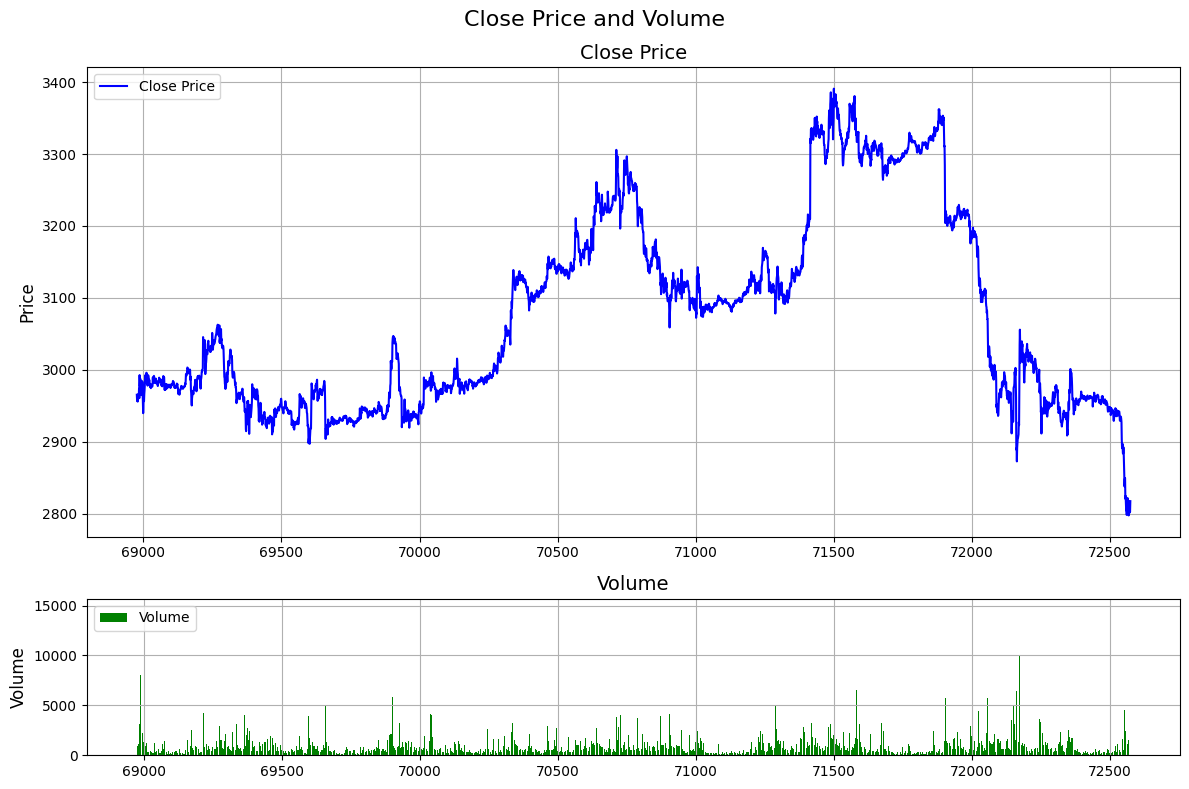

In [22]:
fig, (ax1, ax2) = plt.subplots(
    2, 1,  # 2 строки, 1 столбец
    figsize=(12, 8),  # Размер фигуры
    gridspec_kw={'height_ratios': [3, 1]}
)

# График Close (цена)
ax1.plot(combined_candles.tail(3600).index, combined_candles.tail(3600)['Close'], label='Close Price', color='blue')
ax1.set_title('Close Price', fontsize=14)
ax1.set_ylabel('Price', fontsize=12)
ax1.legend(loc='upper left')
ax1.grid(True)

# График Volume (объем)
ax2.bar(combined_candles.tail(3600).index, combined_candles.tail(3600)['Volume'], label='Volume', color='green')
ax2.set_title('Volume', fontsize=14)
ax2.set_ylabel('Volume', fontsize=12)
ax2.legend(loc='upper left')
ax2.grid(True)

# Настройка общего заголовка
plt.suptitle('Close Price and Volume', fontsize=16)

# Отображение графиков
plt.tight_layout()
plt.show()

In [23]:
combined_candles.describe()

,timestamp,Open,High,Low,Close,Volume
count,72575,72575.000000,72575.000000,72575.000000,72575.000000,72575.000000
mean,2025-01-13 00:00:00,3058.111722,3065.216643,3050.650204,3058.118898,1860.948426
min,2024-01-01 00:15:00,1397.840000,1422.690000,1384.840000,1397.840000,36.000000
25%,2024-07-08 00:07:30,2528.965000,2534.560000,2523.445000,2528.985000,739.000000
50%,2025-01-13 00:00:00,3056.150000,3064.310000,3047.170000,3056.150000,1284.000000
75%,2025-07-20 23:52:30,3512.530000,3519.865000,3504.900000,3512.530000,2197.000000
max,2026-01-25 23:45:00,4942.630000,4956.720000,4934.540000,4942.630000,383820.000000
std,NaN,700.287370,701.662425,698.797369,700.282235,2965.609885
